In [1]:
import os
from collections import defaultdict

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, dataset

from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import sys

# This assumes the script is in 'project_root/experiments/reproduce_table1'
sys.path.append("../../")

try:
    from development import (
        Sequential,
        Conv2d,
        ConstantPad2d,
        BatchNorm2d,
        ReLU,
        MaxPool2d,
        Flatten,
        Linear,
        EarlyStopper,
        QuantizationGranularity,
        QuantizationScheme,
        ConfigEncoder, 
        evolutionary_search_compression_config,
    )
except ImportError:
    print("Error: Could not import the 'development' module.")
    print("Please ensure this script is run from 'experiments/reproduce_table1/'")
    print("and the 'development' module is in the project root ('../../').")


/home/matthias/Documents/EmbeddedAI/deep-microcompression/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import development.experiments.resnet as resnet
import development.experiments.cifar100 as cifar100

In [3]:
LUCKY_NUMBER = 25

# Check for a GPU, defaults to the cpu
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


BASELINE_MODEL_FILE = "lenet5_state_dict.pth"
INPUT_SHAPE = (1, 28, 28)
DATASET_DIR = "../../Datasets"

# Set random seed for reproducibility
torch.manual_seed(LUCKY_NUMBER)
if DEVICE == "cuda":
    torch.cuda.manual_seed(LUCKY_NUMBER)
# cuDNN determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)


/home/matthias/Documents/EmbeddedAI/deep-microcompression/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Using device: cpu


In [4]:
# lenet5_model_parameters = defaultdict(list)
# for file in os.listdir("."):
#     if file.startswith("experiments"):
#         length = None
#         for key, value in torch.load(file, weights_only=False)["nas_parameters"].items():
#             lenet5_model_parameters[key].extend(value)
#             assert length is None or length == len(lenet5_model_parameters[key]), \
#                 f"the length of the value of {key} doesnot match the previous value of {length}"
#             length = len(lenet5_model_parameters[key])
# print(length)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Getting Base Model

In [6]:
train_loader, test_loader = cifar100.get_data_loaders()
baseline_model = resnet.get_model()
baseline_model.to(device=DEVICE)
metric = cifar100.get_metric()
calibration_data = next(iter(train_loader))[0].to(device=DEVICE)


Loading CIFAR100 dataset...

--- STAGE 1: Loading Pretrained Baseline ---


/home/matthias/Documents/EmbeddedAI/deep-microcompression/development/experiments/../../development/layers/branch.py:46: UserWarning: sublayer 1 of type <class 'development.layers.block.Block'> and sublayer2 None have only one of themas a compression parameter modifying layer (it recomputes its parameters) like Linear or Conv but the other uses the parameters from the previous layers, this will result in the modifying layer having it parameters tied to that of the non modifying layer.
  warnings.warn((f"sublayer 1 of type {type(sublayer1)} and sublayer2 {sublayer2} have only one of them"


  All 344 tensors transferred successfully.
  Param count check passed: 861,620 params in both models.


In [7]:
nas_encoder = ConfigEncoder(
    baseline_model, 
)

In [8]:
def get_nas_parameters(nas_file):
    nas_parameters_dict = torch.load(os.path.join("/home/matthias/Downloads", nas_file), weights_only=False)
    nas_parameter = nas_parameters_dict["nas_parameters"]

    return nas_parameter

nas_file_list = ["experiments_resnet_cifar100_nas_parameters.pth-(50)-(1778691612)-(train-True)",
                  "experiments_resnet_cifar100_nas_parameters.pth-(100)-(1779203478)-(train-True)"]

combined_nas_parameter_dict = defaultdict(list)
for nas_file in nas_file_list:
    for key, values in get_nas_parameters(nas_file).items():
        combined_nas_parameter_dict[key].extend(values)

nas_len = len(next(iter(combined_nas_parameter_dict.values())))
for k, v in combined_nas_parameter_dict.items():
    print(k, len(v))
# metric_values = combined_nas_parameter_dict.pop("metric")
nas_len

prune_channel.sparsity.conv2d_0 150
prune_channel.sparsity.branch_0 150
prune_channel.sparsity.branch_1 150
prune_channel.sparsity.branch_2 150
prune_channel.sparsity.branch_3 150
prune_channel.sparsity.branch_4 150
prune_channel.sparsity.branch_5 150
prune_channel.sparsity.branch_6 150
prune_channel.sparsity.branch_7 150
prune_channel.sparsity.branch_8 150
prune_channel.sparsity.branch_9 150
prune_channel.sparsity.branch_10 150
prune_channel.sparsity.branch_11 150
prune_channel.sparsity.branch_12 150
prune_channel.sparsity.branch_13 150
prune_channel.sparsity.branch_14 150
prune_channel.sparsity.branch_15 150
prune_channel.sparsity.branch_16 150
prune_channel.sparsity.branch_17 150
prune_channel.sparsity.branch_18 150
prune_channel.sparsity.branch_19 150
prune_channel.sparsity.branch_20 150
prune_channel.sparsity.branch_21 150
prune_channel.sparsity.branch_22 150
prune_channel.sparsity.branch_23 150
prune_channel.sparsity.branch_24 150
prune_channel.sparsity.branch_25 150
prune_channe

150

In [ ]:
encoded_data = nas_encoder.encode(combined_nas_parameter_dict, with_metric=True)

In [10]:
encoded_data

tensor([[11.,  4.,  3.,  ...,  1.,  0.,  1.],
        [ 3., 15.,  9.,  ...,  0.,  1.,  1.],
        [ 8.,  4.,  7.,  ...,  1.,  0.,  1.],
        ...,
        [13.,  8.,  8.,  ...,  0.,  1.,  1.],
        [ 9.,  9.,  8.,  ...,  1.,  0.,  1.],
        [14.,  6., 10.,  ...,  0.,  1.,  1.]])

In [11]:


def define_model(input_dim, hidden_dim=256, dropout=.2):
    class ResidualBlock(nn.Module):
        def __init__(self, dim, dropout):
            super().__init__()
            self.block = nn.Sequential(
                nn.Linear(dim, dim),
                nn.BatchNorm1d(dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(dim, dim),
                nn.BatchNorm1d(dim)
            )
            self.activation = nn.GELU()

        def forward(self, x):
            # The skip connection helps the model learn small performance variations
            return self.activation(x + self.block(x))

    class ImprovedModel(nn.Module):
        def __init__(self, input_dim, hidden_dim=128, dropout=0.1):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU()
            )
            self.res1 = ResidualBlock(hidden_dim, dropout)
            self.res2 = ResidualBlock(hidden_dim, dropout)
            self.head = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            x = self.stem(x)
            x = self.res1(x)
            x = self.res2(x)
            return self.head(x)
        
    return ImprovedModel(input_dim, hidden_dim, dropout)


In [12]:
estimator = define_model(input_dim=encoded_data.size(1)-1, hidden_dim=256, dropout=.2).to(device)
batch_size = 128
epochs = 2000

optimizer_fun = torch.optim.AdamW(estimator.parameters(), lr=1e-3)
# criterion_fun = nn.MSELoss()
criterion_fun = nn.HuberLoss()
early_stopper = EarlyStopper(
    monitor_metric="validation_loss",
    delta=1e-7,
    mode="min",
    # patience=early_stopper_patience,
    restore_best_state_dict=True,
)


In [13]:
X, Y = encoded_data[:, :-1], encoded_data[:, -1:]
x_mu = X.mean(dim=0)
x_std = X.std(dim=0)
x_std = torch.where(x_std > 1e-10, x_std, torch.ones_like(x_std))


y_mu = Y.mean(dim=0)
y_std = Y.std(dim=0)
y_std = torch.where(y_std > 1e-10, y_std, torch.ones_like(y_std))

def normalise_x(X):
    return (X -x_mu) / x_std

X_norm = normalise_x(X)
Y_norm = (Y -y_mu) / y_std

def unnormise_y(y):
    return (y * y_std) + y_mu



In [14]:
split_index = int(encoded_data.size(0) * .2)
X_train, X_test = X_norm[split_index:], X_norm[split_index:]
Y_train, Y_test = Y_norm[split_index:], Y_norm[split_index:]

In [15]:

estimator_train_loader = DataLoader(
    TensorDataset(X_train, Y_train), 
    batch_size=batch_size, shuffle=True
)
estimator_val_loader = DataLoader(
    TensorDataset(X_test, Y_test), 
    batch_size=batch_size, shuffle=False
)

In [16]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fun, T_max=epochs, eta_min=1e-6
)

In [17]:

history = {"train_loss": [], "validation_loss": [], "train_l1": [], "validation_l1": [], "lr": []}

l1_loss = nn.L1Loss()

# 3. Training Loop
for epoch in range(epochs):
    estimator.train()
    total_train_loss = 0
    total_train_l1_loss = 0

    for batch_x, batch_y in estimator_train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer_fun.zero_grad()
        pred = estimator(batch_x)
        loss = criterion_fun(pred, batch_y)
        loss.backward()
        optimizer_fun.step()
        total_train_loss += loss.item()

        total_train_l1_loss += l1_loss(unnormise_y(pred), unnormise_y(batch_y)).item()
    
    # 4. Validation Phase
    estimator.eval()
    total_val_loss = 0
    total_val_l1_loss = 0

    with torch.no_grad():
        for val_x, val_y in estimator_val_loader:
            val_x = val_x.to(device)
            val_y = val_y.to(device)
            val_pred = estimator(val_x)
            v_loss = criterion_fun(val_pred, val_y)
            total_val_loss += v_loss.item()
    
            total_val_l1_loss += l1_loss(unnormise_y(val_pred), unnormise_y(val_y)).item()
            
    avg_train_loss = total_train_loss / len(estimator_train_loader)
    avg_val_loss = total_val_loss / len(estimator_val_loader)
    avg_train_l1_loss = total_train_l1_loss / len(estimator_train_loader)
    avg_val_l1_loss = total_val_l1_loss / len(estimator_val_loader)
    
    # Record metrics
    history["train_loss"].append(avg_train_loss)
    history["validation_loss"].append(avg_val_loss)

    history["train_l1"].append(avg_train_l1_loss)
    history["validation_l1"].append(avg_val_l1_loss)

    history["lr"].append(optimizer_fun.param_groups[0]['lr'])

    # 5. Step Scheduler & Early Stopper
    scheduler.step()
    
    # Pass metrics to early stopper (assuming standard API)
    # If your EarlyStopper is custom, it may need the estimator state
    # stop = early_stopper(
    #     history=history, 
    #     model=estimator, 
    #     epoch=epoch
    # )
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f} | LR: {history['lr'][-1]:.6f}")

    # if stop:
    #     print(f"Early stopping triggered at epoch {epoch+1}")
    #     break

Epoch 10/2000 | Train Loss: 0.07888 | Val Loss: 0.08279 | LR: 0.001000
Epoch 20/2000 | Train Loss: 0.03948 | Val Loss: 0.03286 | LR: 0.001000
Epoch 30/2000 | Train Loss: 0.06511 | Val Loss: 0.02273 | LR: 0.000999
Epoch 40/2000 | Train Loss: 0.02466 | Val Loss: 0.01579 | LR: 0.000999
Epoch 50/2000 | Train Loss: 0.02423 | Val Loss: 0.01974 | LR: 0.000999
Epoch 60/2000 | Train Loss: 0.01298 | Val Loss: 0.01491 | LR: 0.000998
Epoch 70/2000 | Train Loss: 0.01059 | Val Loss: 0.01754 | LR: 0.000997
Epoch 80/2000 | Train Loss: 0.01217 | Val Loss: 0.00469 | LR: 0.000996
Epoch 90/2000 | Train Loss: 0.00704 | Val Loss: 0.00342 | LR: 0.000995
Epoch 100/2000 | Train Loss: 0.01509 | Val Loss: 0.00935 | LR: 0.000994
Epoch 110/2000 | Train Loss: 0.01126 | Val Loss: 0.00370 | LR: 0.000993
Epoch 120/2000 | Train Loss: 0.01373 | Val Loss: 0.00576 | LR: 0.000991
Epoch 130/2000 | Train Loss: 0.01960 | Val Loss: 0.00468 | LR: 0.000990
Epoch 140/2000 | Train Loss: 0.00671 | Val Loss: 0.00739 | LR: 0.000988
E

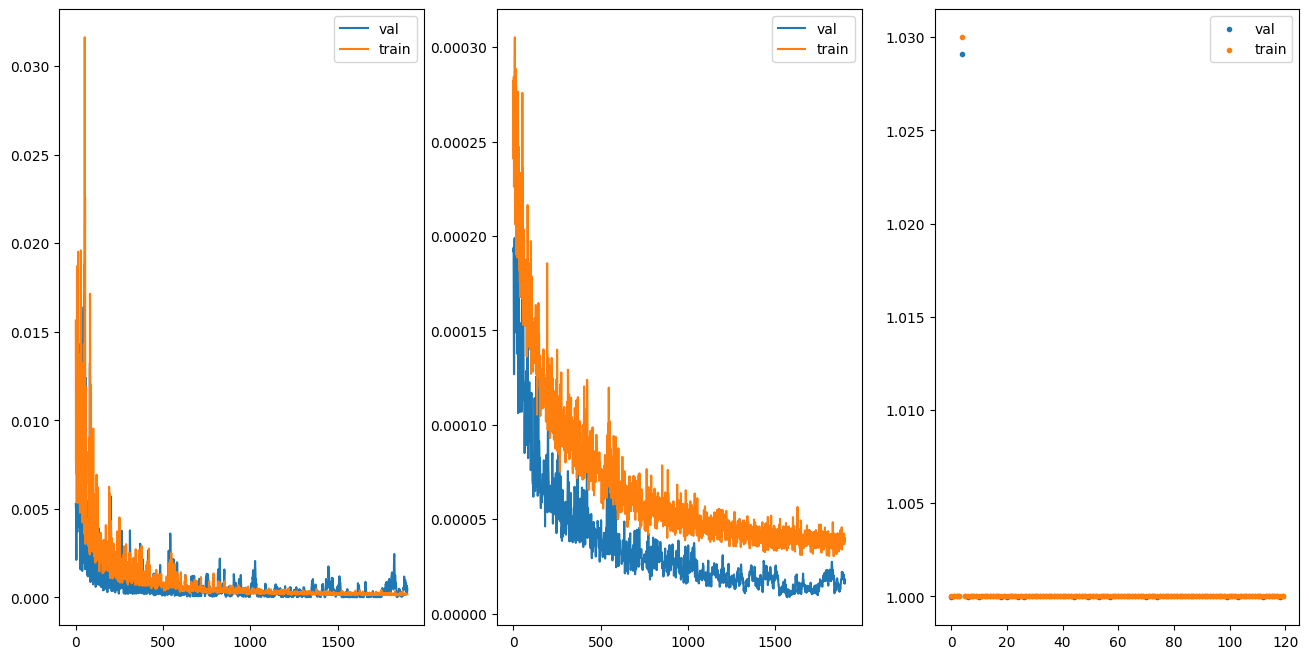

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

axes[0].plot(history["validation_loss"][100:], label="val")
axes[0].plot(history["train_loss"][100:], label="train")

axes[0].legend()

axes[1].plot(history["validation_l1"][100:], label="val")
axes[1].plot(history["train_l1"][100:], label="train")

axes[1].legend()


axes[2].scatter(range(len(Y_test)), unnormise_y(estimator(X_test)).detach().cpu().numpy().squeeze(), marker=".", label="val")
axes[2].scatter(range(len(Y_test)), unnormise_y(Y_test).detach().cpu().numpy().squeeze(), marker=".", label="train")

axes[2].legend()

In [19]:

def get_search_for_smallest_best_condition(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def condition(metric, size, ram, config):
        # filter out not static quantization
        if config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if ram / original_workspace_size > .25:
            return False
        # filter out if model size cannot size in flash
        if size / original_model_size > .25:
            return False
        # print(metric)
        # if original_metric - metric > 5:
        #     return False
        # print(metric, size, ram, config)
        return True
    
    return condition



def get_search_for_smallest_best_condition_specific_to_bard(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def condition(metric, size, ram, config):
        # filter out not static quantization
        if config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if ram > 1400:
            return False
        # filter out if model size cannot size in flash
        if size > 20*1024:
            return False
        # print(metric)
        # if original_metric - metric > 5:
        #     return False
        # print(metric, size, ram, config)
        return True
    
    return condition

def get_model_filter_for_nas(baseline_model, input_shape):

    original_workspace_size = baseline_model.get_workspace_size(input_shape=input_shape)
    original_model_size = baseline_model.get_size_in_bytes()

    def model_filter_for_nas(compressed_model:Sequential, compression_config):
        # filter out not static quantization
        if compression_config["quantize"]["scheme"] != QuantizationScheme.STATIC:
            return False
        # filter out if activation cannot size in ram
        if compressed_model.get_workspace_size(input_shape=input_shape) / original_workspace_size > .25:
            return False
        # filter out if model size cannot size in flash
        if compressed_model.get_size_in_bytes() / original_model_size > .25:
            return False
        return True
    
    return model_filter_for_nas


In [20]:
def estimate(config):
    encoded_config = nas_encoder(config, with_metric=False).to(device).unsqueeze(0)
    X = normalise_x(encoded_config)
    Y = estimator(X)
    return unnormise_y(Y).item()


In [21]:

importance = .5
calibration_data = next(iter(train_loader))[0].to(device=device)

original_model_size = baseline_model.get_size_in_bytes()
# Note: condition depends on estimator scale. Assuming estimator predicts 0-100 accuracy.
best_configuration, best_result_info = evolutionary_search_compression_config(
    baseline_model,
    estimate,
    INPUT_SHAPE,
    calibration_data,
    condition=get_search_for_smallest_best_condition(baseline_model, INPUT_SHAPE), 
    objective= lambda metric, size, ram, config: size/original_model_size *100 - importance * metric, 
    filter=get_model_filter_for_nas(baseline_model, INPUT_SHAPE),
    maximize=False, # Minimize Size
    verbose=True,
    population_size=75,
    generations=75
)


best_configuration = baseline_model.decode_compression_dict_hyperparameter(best_configuration)
best_configuration

/home/matthias/Documents/EmbeddedAI/deep-microcompression/development/experiments/../../development/layers/batchnorm.py:125: UserWarning: You are preforming static quantization with a model with batchnorm,  it best to fuse it first before quantizing the model
  warnings.warn("You are preforming static quantization with a model with batchnorm, "
  0%|          | 0/75 [00:00<?, ?it/s]

Gen 0: ✔ New best! Obj=2.2332 Metric=1.0000 Size=94200.0000 Ram=3675.0000
Gen 0: ✔ New best! Obj=1.1751 Metric=1.0039 Size=57799.0000 Ram=3920.0000
Gen 0: ✔ New best! Obj=0.2110 Metric=0.9999 Size=24503.0000 Ram=3920.0000
Gen 0: ✔ New best! Obj=-0.0989 Metric=1.0002 Size=13826.0000 Ram=1960.0000
Gen 0: ✔ New best! Obj=-0.2198 Metric=1.0003 Size=9662.0000 Ram=1176.0000


  1%|▏         | 1/75 [02:02<2:30:58, 122.41s/it]

Gen 0/75 Complete. Avg Score: 4.4064


  3%|▎         | 2/75 [04:11<2:33:21, 126.05s/it]

...

 99%|█████████▊| 74/75 [2:26:01<01:51, 111.48s/it]

Gen 73/75 Complete. Avg Score: -0.4352


100%|██████████| 75/75 [2:27:49<00:00, 118.26s/it]

Gen 74/75 Complete. Avg Score: -0.4358


{'prune_channel': {'sparsity': {'conv2d_0': 14,
   'branch_0': 11,
   'branch_1': 0,
   'branch_2': 3,
   'branch_3': 0,
   'branch_4': 10,
   'branch_5': 11,
   'branch_6': 15,
   'branch_7': 13,
   'branch_8': 7,
   'branch_9': 30,
   'branch_10': 10,
   'branch_11': 30,
   'branch_12': 25,
   'branch_13': 21,
   'branch_14': 7,
   'branch_15': 26,
   'branch_16': 9,
   'branch_17': 1,
   'branch_18': 63,
   'branch_19': 1,
   'branch_20': 33,
   'branch_21': 44,
   'branch_22': 38,
   'branch_23': 5,
   'branch_24': 21,
   'branch_25': 51,
   'branch_26': 16},
  'metric': 'l2'},
 'quantize': {'scheme': <QuantizationScheme.STATIC: 3>,
  'activation_bitwidth': 8,
  'parameter_bitwidth': {'conv2d_0': 2,
   'branch_0': 2,
   'branch_1': 2,
   'branch_2': 2,
   'branch_3': 2,
   'branch_4': 2,
   'branch_5': 2,
   'branch_6': 2,
   'branch_7': 2,
   'branch_8': 4,
   'branch_9': 2,
   'branch_10': 2,
   'branch_11': 2,
   'branch_12': 2,
   'branch_13': 2,
   'branch_14': 2,
   'branch_1

In [22]:
print(f"Searching for smallest config to fit in board with")
best_configuration, best_result_info = evolutionary_search_compression_config(
    baseline_model,
    estimate,
    INPUT_SHAPE,
    calibration_data,
    condition=get_search_for_smallest_best_condition_specific_to_bard(baseline_model, INPUT_SHAPE), 
    objective= lambda metric, size, ram, config: metric, 
    filter=get_model_filter_for_nas(baseline_model, INPUT_SHAPE),
    maximize=True, # Minimize Size
    verbose=True,
    population_size=75,
    generations=75
)

best_configuration = baseline_model.decode_compression_dict_hyperparameter(best_configuration)
print(f"best configuration: {best_configuration}\nbest_result_info: {best_result_info}")


Searching for smallest config to fit in board with


  0%|          | 0/75 [00:00<?, ?it/s]

Gen 0: ✔ New best! Obj=1.0005 Metric=1.0005 Size=9303.0000 Ram=1176.0000


  1%|▏         | 1/75 [01:49<2:15:22, 109.76s/it]

Gen 0/75 Complete. Avg Score: 1.0002
Gen 1: ✔ New best! Obj=1.0006 Metric=1.0006 Size=9311.0000 Ram=1176.0000
Gen 1: ✔ New best! Obj=1.0008 Metric=1.0008 Size=9427.0000 Ram=1176.0000


...

Gen 72/75 Complete. Avg Score: 1.0269
Gen 73: ✔ New best! Obj=1.0274 Metric=1.0274 Size=10343.0000 Ram=1176.0000


 99%|█████████▊| 74/75 [2:33:46<02:34, 154.28s/it]

Gen 73/75 Complete. Avg Score: 1.0270


100%|██████████| 75/75 [2:36:02<00:00, 124.84s/it]

Gen 74/75 Complete. Avg Score: 1.0271
best configuration: {'prune_channel': {'sparsity': {'conv2d_0': 13, 'branch_0': 12, 'branch_1': 2, 'branch_2': 4, 'branch_3': 14, 'branch_4': 13, 'branch_5': 15, 'branch_6': 7, 'branch_7': 15, 'branch_8': 0, 'branch_9': 28, 'branch_10': 10, 'branch_11': 26, 'branch_12': 29, 'branch_13': 31, 'branch_14': 6, 'branch_15': 28, 'branch_16': 0, 'branch_17': 2, 'branch_18': 62, 'branch_19': 2, 'branch_20': 54, 'branch_21': 26, 'branch_22': 7, 'branch_23': 5, 'branch_24': 49, 'branch_25': 61, 'branch_26': 60}, 'metric': 'l2'}, 'quantize': {'scheme': <QuantizationScheme.STATIC: 3>, 'activation_bitwidth': 2, 'parameter_bitwidth': {'conv2d_0': 4, 'branch_0': 2, 'branch_1': 2, 'branch_2': 2, 'branch_3': 2, 'branch_4': 4, 'branch_5': 4, 'branch_6': 4, 'branch_7': 4, 'branch_8': 4, 'branch_9': 4, 'branch_10': 4, 'branch_11': 4, 'branch_12': 4, 'branch_13': 2, 'branch_14': 8, 'branch_15': 8, 'branch_16': 2, 'branch_17': 8, 'branch_18': 2, 'branch_19': 4, 'branch_

In [23]:


    def fit(self, epochs, batch_size=64):
        """
        Trains the estimator with Cosine Annealing and Early Stopping.
        """
        # 1. Data Preparation & Standardization
        X, Y = self.data[:, :-1], self.data[:, -1].unsqueeze(dim=1)
        N = X.size(0)
        assert N > 1, "The number of data points is less than 2."
        
        # Standardization fit
        self._standardize_fit_x(X)
        X_norm = self._standardize_transform_x(X)
        self._standardize_fit_y(Y)
        Y_norm = self._standardize_transform_y(Y)

        # Train/Val Split
        idx = torch.randperm(N, device=self.device)
        n_val = max(1, int(N * 0.2))
        val_idx, train_idx = idx[:n_val], idx[n_val:]
        
        train_loader = DataLoader(
            TensorDataset(X_norm[train_idx], Y_norm[train_idx]), 
            batch_size=batch_size, shuffle=True
        )
        val_loader = DataLoader(
            TensorDataset(X_norm[val_idx], Y_norm[val_idx]), 
            batch_size=batch_size, shuffle=False
        )

        # 2. Setup Scheduler (Cosine Annealing)
        # T_max is set to the total epochs to complete one full cycle
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer_fun, T_max=epochs, eta_min=1e-6
        )
        
        history = {"train_loss": [], "validation_loss": [], "lr": []}

        # 3. Training Loop
        for epoch in range(epochs):
            self.model.train()
            total_train_loss = 0
            
            for batch_x, batch_y in train_loader:
                self.optimizer_fun.zero_grad()
                pred = self.model(batch_x)
                loss = self.criterion_fun(pred, batch_y)
                loss.backward()
                self.optimizer_fun.step()
                total_train_loss += loss.item()
            
            # 4. Validation Phase
            self.model.eval()
            total_val_loss = 0
            with torch.no_grad():
                for val_x, val_y in val_loader:
                    val_pred = self.model(val_x)
                    v_loss = self.criterion_fun(val_pred, val_y)
                    total_val_loss += v_loss.item()
            
            avg_train_loss = total_train_loss / len(train_loader)
            avg_val_loss = total_val_loss / len(val_loader)
            
            # Record metrics
            history["train_loss"].append(avg_train_loss)
            history["validation_loss"].append(avg_val_loss)
            history["lr"].append(self.optimizer_fun.param_groups[0]['lr'])

            # 5. Step Scheduler & Early Stopper
            scheduler.step()
            
            # Pass metrics to early stopper (assuming standard API)
            # If your EarlyStopper is custom, it may need the model state
            stop = self.early_stopper(
                history=history, 
                model=self.model, 
                epoch=epoch
            )
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f} | LR: {history['lr'][-1]:.6f}")

            if stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
                
        return history
    

        assert len(list(data.values())[0]) > 2, f"The data must have more than two datapoints got {len(list(data.values())[0])}"
        self.encoder = ConfigEncoder(search_space=search_space, device=self.device)
        self.data = self.encoder(data, with_metric=True)
        # self.x_mu = torch.tensor([0.0])
        # self.x_std = torch.tensor([1.0])


        self.optimizer_fun = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        self.criterion_fun = nn.MSELoss()


    def fit(self, epochs, batch_size=32):
        """
        Trains the estimator on the provided data.
        """
        self.model.train()
        X, Y = self.data[:, :-1], self.data[:, -1].unsqueeze(dim=1)
        
        self.x_mu = X.mean(dim=0).to(self.device)
        x_std = X.std(dim=0)
        self.x_std = torch.where(x_std > 1e-10, x_std, torch.ones_like(x_std)).to(self.device)

        N = X.size(0)
        assert N > 1, "The number of data points is less than 2."
        
        # Standardization fit
        self._standardize_fit_x(X)
        X_norm = self._standardize_transform_x(X)
        self._standardize_fit_y(Y)
        Y_norm = self._standardize_transform_y(Y)

        # Train/Val Split
        idx = torch.randperm(N, device=self.device)
        n_val = max(1, int(N * 0.2))
        val_idx, train_idx = idx[:n_val], idx[n_val:]
        X_train, Y_train = X_norm[train_idx], Y_norm[train_idx]
        X_val, Y_val = X_norm[val_idx], Y_norm[val_idx]

        train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=64, shuffle=False)

        history = self.model.fit(
            train_dataloader=train_loader, 
            epochs=epochs, 
            criterion_fun=self.criterion_fun, 
            optimizer_fun=self.optimizer_fun, 
            validation_dataloader=val_loader,
            metrics={
                "mse": lambda y_pred, y_true: torch.pow((y_pred - y_true), 2).mean().item(), 
                "rmse": lambda y_pred, y_true: torch.sqrt(torch.pow((y_pred - y_true), 2).mean()).item(),
                "abs": lambda y_pred, y_true: (y_pred- y_true).abs().mean().item(),
            },
            device=self.device, 
            batch_size=batch_size
        )
        return history
        
    def _standardize_fit_x(self, Y):

        self.x_mu = Y.mean(dim=0)
        x_std = Y.std(dim=0)
        self.x_std = torch.where(x_std > 1e-10, x_std, torch.ones_like(x_std)).to(self.device)

    def _standardize_transform_x(self, x):
        return (x -self.x_mu) / self.x_std
    
    def _standardize_inverse_transform_x(self, x):
        return (x * self.x_std) + self.x_mu
    
    
    def _standardize_fit_y(self, Y):

        self.y_mu = Y.mean(dim=0)
        y_std = Y.std(dim=0)
        self.y_std = torch.where(y_std > 1e-10, y_std, torch.ones_like(y_std)).to(self.device)

    def _standardize_transform_y(self, y):
        return (y -self.y_mu) / self.y_std
    
    def _standardize_inverse_transform_y(self, y):
        return (y * self.y_std) + self.y_mu


    @torch.no_grad()
    def predict(self, config:Dict[str, Any], return_standardize=False):
        """
        Predicts the metric for a given input configuration.
        """
        X = self.encoder(config, with_metric=False)
        
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32, device=self.device)
        else:
            X = X.to(dtype=torch.float32, device=self.device)

        X = self._standardize_transform_x(X)
        self.model.eval()

        if X.dim() == 1:
            X = X.unsqueeze(0)
        Y = self.model(X).item()

        if not return_standardize:
            Y = self._standardize_inverse_transform_y(Y)
        return Y


NameError: name 'Dict' is not defined

In [ ]:
lenet5_model_parameters

defaultdict(list,
            {'prune_channel.sparsity.conv2d_0': [3,
              3,
              3,
              0,
              0,
              5,
              2,
              3,
              2,
              2,
              5,
              5,
              3,
              5,
              0,
              4,
              1,
              0,
              2,
              5,
              3,
              5,
              5,
              3,
              1,
              3,
              0,
              3,
              0,
              5,
              5,
              0,
              4,
              5,
              4,
              4,
              3,
              5,
              4,
              5,
              5,
              5,
              1,
              4,
              4,
              3,
              4,
              1,
              5,
              0,
              4,
              3,
              5,
              5,
              2,
            